# Model Training

## Imports & Configuration

In [2]:
import torch
import torchvision
from torchvision import transforms
import os
import json
import random
import numpy as np
import cv2
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import torchvision.models as models
import torchvision.transforms as T

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4080


## Dataset & Dataloader

In [4]:
os.chdir("..")

In [5]:
DATASET_PATH = "data/dataset"

MODEL_PATH = "weights"
METRICS_PATH = "metrics"

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(METRICS_PATH, exist_ok=True)

## Augmentation

In [6]:
def augment_image(img):

    h, w = img.shape[:2]

    # Horizontal flip
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)

    # Rotation
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-15, 15)
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
        rotation = cv2.warpAffine(img, M, (w, h))
        rotate_crop = rotation[25:h-25, 25:w-25]
        img = cv2.resize(rotate_crop, (w, h))

    # Brightness
    if np.random.rand() < 0.5:
        img = cv2.convertScaleAbs(img, alpha=1, beta=40)

    # Contrast
    if np.random.rand() < 0.5:
        img = cv2.convertScaleAbs(img, alpha=1.5, beta=0)

    # Zoom
    if np.random.rand() < 0.5:
        crop = img[40:h-40, 40:w-40]
        img = cv2.resize(crop, (w, h))

    return img

## Dataset & Dataloader

In [18]:
class LandmarkDataset(Dataset):

    def __init__(self, samples, labels, augment=False):
        self.samples = samples
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path = self.samples[idx]
        label = self.labels[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.augment:
            img = augment_image(img)
            alpha = np.random.uniform(0.8, 1.2)  # contrast
            beta = np.random.uniform(-20, 20)    # brightness
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

        img = img / 255.0
        img = np.transpose(img, (2,0,1))

        img = torch.tensor(img, dtype=torch.float32)

        return img, label

In [19]:
class_names = sorted(os.listdir(DATASET_PATH))

class_to_idx = {cls:i for i,cls in enumerate(class_names)}

samples = []
labels = []

for cls in class_names:

    folder = os.path.join(DATASET_PATH, cls)

    for img in os.listdir(folder):

        samples.append(os.path.join(folder, img))
        labels.append(class_to_idx[cls])

In [20]:
samples[:5], samples[50:55]

(['data/dataset\\Big_Ben\\Big_Ben_1.jpg',
  'data/dataset\\Big_Ben\\Big_Ben_10.jpg',
  'data/dataset\\Big_Ben\\Big_Ben_11.jpg',
  'data/dataset\\Big_Ben\\Big_Ben_12.jpg',
  'data/dataset\\Big_Ben\\Big_Ben_13.jpg'],
 ['data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_1.jpg',
  'data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_10.jpg',
  'data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_11.jpg',
  'data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_12.jpg',
  'data/dataset\\Christ_The_Redeemer\\Christ_The_Redeemer_13.jpg'])

In [21]:
labels[:5], labels[50:55]

([0, 0, 0, 0, 0], [1, 1, 1, 1, 1])

### Train/Val split

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    samples,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

### Dataloader

In [23]:
train_dataset = LandmarkDataset(X_train, y_train, augment=True)
val_dataset = LandmarkDataset(X_val, y_val, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

## Baseline Model (Simple CNN)

In [28]:
class BaselineCNN(nn.Module): # Custom VGG

    def __init__(self, num_classes):
      super().__init__()

      # 224 * 224 * 3
      self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))

      # 112 * 112 * 64
      self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))

      # 56 * 56 * 128
      self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Dropout(0.25))
      
      # 1 * 1 * 256
      self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1 * 1 * 256, 512),
            nn.ReLU())
      self.fc2 = nn.Linear(in_features=512, out_features=num_classes)
    
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = torch.flatten(out, 1)
        out = self.fc1(out)
        out = self.fc2(out)

        return out

### Training Loop

In [29]:
def train_epoch(model, loader, criterion, optimizer):

    model.train()

    losses = []

    for imgs, labels in loader:

        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)

### Validation

In [37]:
def validate_epoch(model, loader, criterion):

    model.eval()

    losses = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            losses.append(loss.item())

    return np.mean(losses)

### Count Metrics

In [31]:
def evaluate_metrics(model, loader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    
    return acc, f1

### Train

In [32]:
EPOCHS = 20

train_losses = []
val_losses = []
val_accuracies = []
val_f1s = []

baseline = BaselineCNN(num_classes=len(class_names)).to(DEVICE)
total_params = sum(p.numel() for p in baseline.parameters())
print(f"Model params: {total_params}")

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(baseline.parameters(), lr=1e-4)

for epoch in range(EPOCHS):

    train_loss = train_epoch(baseline, train_loader, criterion, optimizer)
    val_loss = validate_epoch(baseline, val_loader, criterion)
    
    acc, f1 = evaluate_metrics(baseline, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(acc)
    val_f1s.append(f1)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_acc={acc:.3f} | val_f1={f1:.3f}"
    )

Model params: 1283914
Epoch 1/20 | train_loss=2.2814 | val_loss=2.2889 | val_acc=0.100 | val_f1=0.028
Epoch 2/20 | train_loss=2.1958 | val_loss=2.1423 | val_acc=0.260 | val_f1=0.184
Epoch 3/20 | train_loss=2.1443 | val_loss=2.0994 | val_acc=0.290 | val_f1=0.230
Epoch 4/20 | train_loss=2.1018 | val_loss=2.0991 | val_acc=0.240 | val_f1=0.205
Epoch 5/20 | train_loss=2.0697 | val_loss=1.9897 | val_acc=0.290 | val_f1=0.223
Epoch 6/20 | train_loss=2.0385 | val_loss=1.9890 | val_acc=0.270 | val_f1=0.204
Epoch 7/20 | train_loss=2.0219 | val_loss=1.9896 | val_acc=0.260 | val_f1=0.198
Epoch 8/20 | train_loss=2.0036 | val_loss=1.9398 | val_acc=0.320 | val_f1=0.262
Epoch 9/20 | train_loss=1.9742 | val_loss=1.9825 | val_acc=0.300 | val_f1=0.237
Epoch 10/20 | train_loss=1.9711 | val_loss=1.8777 | val_acc=0.360 | val_f1=0.290
Epoch 11/20 | train_loss=1.9594 | val_loss=1.9288 | val_acc=0.280 | val_f1=0.254
Epoch 12/20 | train_loss=1.8952 | val_loss=1.8655 | val_acc=0.350 | val_f1=0.291
Epoch 13/20 | t

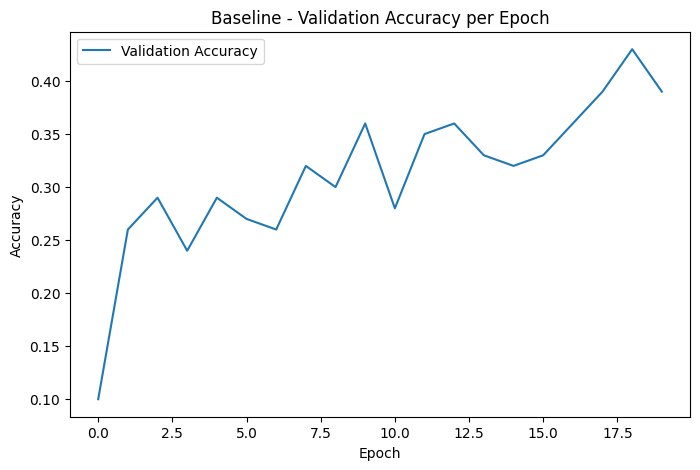

In [41]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline - Validation Accuracy per Epoch")
plt.legend()
plt.savefig("metrics/artifacts/Baseline-accuracy_curve.png")
plt.show()

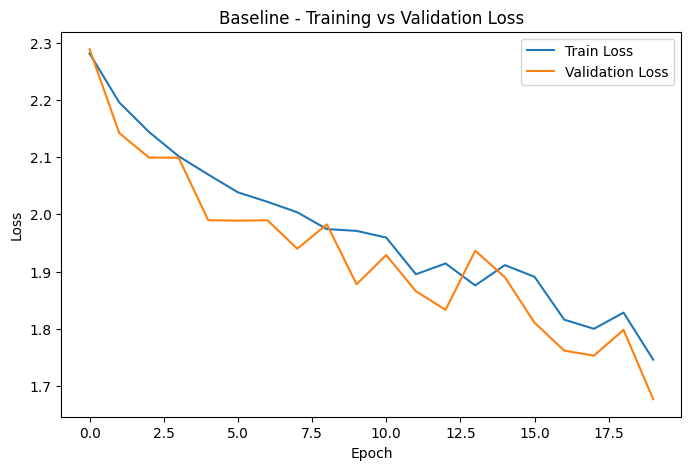

In [42]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline - Training vs Validation Loss")

plt.legend()

plt.savefig("metrics/artifacts/Baseline-loss_curve.png")

plt.show()

#### Save Baseline model

In [35]:
torch.save(baseline.state_dict(), "weights/baseline_model.pth")

In [36]:
def save_metrics_json(
    model, 
    model_name: str, 
    num_classes: int, 
    train_loss: list, 
    val_loss: list, 
    val_accuracy: list, 
    val_f1: list, 
    notes: str = "", 
    save_path: str = "metrics/metrics.json"
):

    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    metrics_dict = {
        "model_name": model_name,
        "num_params": num_params,
        "num_classes": num_classes,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_f1": val_f1,
        "notes": notes
    }

    with open(save_path, "w") as f:
        json.dump(metrics_dict, f, indent=4)

    print(f"Metrics saved to {save_path}")

In [38]:
save_metrics_json(
    model=baseline,
    model_name="BaselineCNN (Changed VGG)",
    num_classes=10,
    train_loss=train_losses,
    val_loss=val_losses,
    val_accuracy=val_accuracies,
    val_f1=val_f1s,
    notes="Baseline CNN (Changed VGG) with 3 conv layers and fc1=512",
    save_path="metrics/baseline_metrics.json"
)

Metrics saved to metrics/baseline_metrics.json


In [40]:
import pandas as pd

baseline_metrics = pd.read_json("metrics/baseline_metrics.json")

baseline_metrics.head()

,model_name,num_params,num_classes,train_loss,val_loss,val_accuracy,val_f1,notes
0,BaselineCNN (Changed VGG),1283914,10,2.281397,2.288889,0.10,0.028348,Baseline CNN (Changed VGG) with 3 conv layers ...
1,BaselineCNN (Changed VGG),1283914,10,2.195824,2.142298,0.26,0.184357,Baseline CNN (Changed VGG) with 3 conv layers ...
2,BaselineCNN (Changed VGG),1283914,10,2.144282,2.099362,0.29,0.229514,Baseline CNN (Changed VGG) with 3 conv layers ...
3,BaselineCNN (Changed VGG),1283914,10,2.101777,2.099131,0.24,0.204680,Baseline CNN (Changed VGG) with 3 conv layers ...
4,BaselineCNN (Changed VGG),1283914,10,2.069665,1.989707,0.29,0.222795,Baseline CNN (Changed VGG) with 3 conv layers ...
